In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import sys
import os
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append(os.getcwd())
SEED = 42
np.random.seed(SEED)
train = pd.read_csv('data/train/train.csv')
val = pd.read_csv('data/train/val.csv')
holdout = pd.read_csv('data/input/holdout.csv')

In [2]:
train

,ID,REGION,BRANCH,CITY,subject,SUBFRMT,TRADE_SQUARE,HuffFamilies,HuffRelativeFamilies,HOSPITAL,...,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,month_count,new_buildings,change_CA,target_1,target_2
0,1,Южный округ,Армавир,Кропоткин,Краснодарский край,2,0.445648,0.019780,0.83,0,...,1,0,3,0.550733,0,318,0,0,175198.181280689,174259.925193
1,2,Южный округ,Новороссийск Запад,Анапа,Краснодарский край,2,0.780890,0.060494,0.83,0,...,1,0,2,1.114666,0,317,0,0,360629.424460479,296286.063051
2,3,Южный округ,Ростов-на-Дону Запад,Таганрог,Ростовская область,2,0.471618,0.033680,0.84,0,...,1,0,2,3.730973,10,315,0,0,252109.534031112,250903.579740
3,4,Кавказский округ,Волгоград Восток,Камышин,Волгоградская область,2,0.555293,0.062644,0.76,0,...,1,0,3,1.039118,15,314,0,0,362653.018943467,351612.980992
4,5,Южный округ,Волгодонск,Волгодонск,Ростовская область,2,0.622970,0.030358,0.93,1,...,1,0,2,1.595111,0,314,0,0,295733.315192993,287970.899275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15104,15105,Сибирский округ,Красноярск,Красноярск,Красноярский край,1,0.419759,0.103733,0.64,0,...,1,0,1,11.306402,0,37,1,0,335833.03570864,335285.135791
15105,15106,Уральский округ,Ноябрьск,Правохеттинский,Ямало-Ненецкий автономный округ,1,0.523817,0.015207,0.48,0,...,1,0,3,0.251115,10,37,0,0,239449.710720112,245862.395965
15106,15107,Южный округ,Волгодонск,Синегорский,Ростовская область,1,0.426907,0.075626,0.54,0,...,1,0,3,1.170235,6,37,0,0,229265.834248059,223720.175478
15107,15108,Южный округ,Ростов-на-Дону Запад,Ростов-на-Дону,Ростовская область,1,0.807060,0.041533,0.93,0,...,1,0,3,6.246047,30,37,0,0,279075.187488385,278484.672897


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15109 entries, 0 to 15108
Data columns (total 56 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          15109 non-null  int64  
 1   REGION                      15109 non-null  object 
 2   BRANCH                      15109 non-null  object 
 3   CITY                        15109 non-null  object 
 4   subject                     15109 non-null  object 
 5   SUBFRMT                     15109 non-null  int64  
 6   TRADE_SQUARE                15109 non-null  float64
 7   HuffFamilies                15109 non-null  float64
 8   HuffRelativeFamilies        15109 non-null  float64
 9   HOSPITAL                    15109 non-null  int64  
 10  KINDERGARTENS               15109 non-null  int64  
 11  BANKS                       15109 non-null  int64  
 12  MK_ON_MM                    15109 non-null  int64  
 13  ROUTES_CNT                  151

0:	learn: 0.6501739	test: 0.6503176	best: 0.6503176 (0)	total: 24.5ms	remaining: 24.5s
100:	learn: 0.0035237	test: 0.0034185	best: 0.0034185 (100)	total: 541ms	remaining: 4.81s
200:	learn: 0.0003119	test: 0.0002595	best: 0.0002595 (200)	total: 1.01s	remaining: 4.01s
300:	learn: 0.0001106	test: 0.0000777	best: 0.0000777 (300)	total: 1.48s	remaining: 3.43s
400:	learn: 0.0000814	test: 0.0000536	best: 0.0000536 (399)	total: 1.88s	remaining: 2.8s
500:	learn: 0.0000803	test: 0.0000528	best: 0.0000528 (500)	total: 2.23s	remaining: 2.23s
600:	learn: 0.0000798	test: 0.0000524	best: 0.0000524 (600)	total: 2.59s	remaining: 1.72s
700:	learn: 0.0000797	test: 0.0000524	best: 0.0000524 (700)	total: 2.94s	remaining: 1.25s
800:	learn: 0.0000797	test: 0.0000523	best: 0.0000523 (800)	total: 3.29s	remaining: 817ms
900:	learn: 0.0000792	test: 0.0000520	best: 0.0000520 (900)	total: 3.63s	remaining: 399ms
999:	learn: 0.0000792	test: 0.0000520	best: 0.0000520 (999)	total: 3.96s	remaining: 0us

bestTest = 5.19

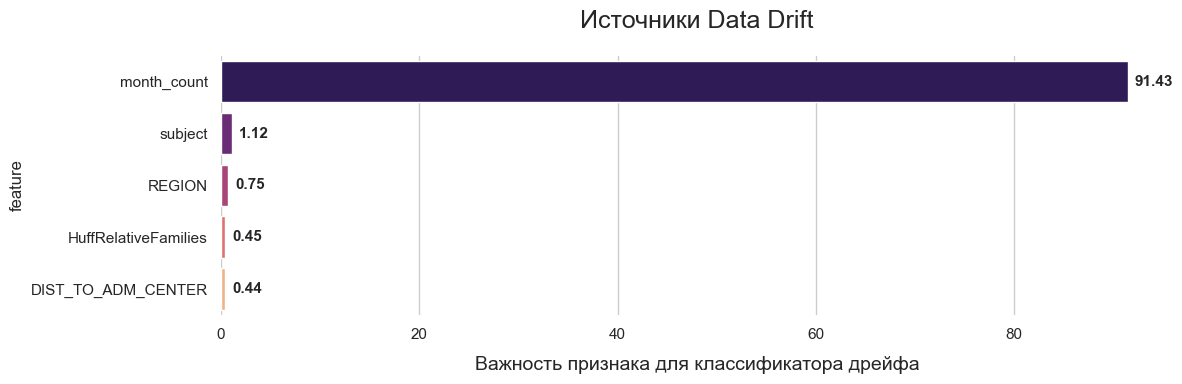

In [19]:

features = train.columns.values

old_data = pd.concat([train, val], axis=0).reset_index(drop=True)
old_data['is_holdout'] = 0
new_data = holdout.copy()
new_data['is_holdout'] = 1
df_adv = pd.concat([old_data, new_data], axis=0).reset_index(drop=True)

features_to_drop = [features[54], features[55],'ID' ,'is_holdout']
X = df_adv.drop(columns=[col for col in features_to_drop if col in df_adv.columns])
y = df_adv['is_holdout']

cat_features = features[1:5]

cat_features = [c for c in cat_features if c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=6,
    cat_features=cat_features,
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))

probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print(f"\nROC-AUC Adversarial Validation: {auc:.4f}")
importances = model.get_feature_importance(type='FeatureImportance')
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nТоп признаков, по которым holdout отличается от train/val:")
print(feature_importance_df.head(10))

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Настройка стиля
sns.set_theme(style="whitegrid") # Чистый белый фон с сеткой
plt.figure(figsize=(12, 4))

# 2. Подготовка данных (сортировка для красоты)
plot_data = feature_importance_df.sort_values('importance', ascending=False).head(5)

# 3. Построение графика
# Используем палитру 'viridis' или 'magma' — они выглядят профессионально
ax = sns.barplot(
    x='importance', 
    y='feature', 
    data=plot_data, 
    palette='magma',
    hue='feature', # Для автоматического раскраса
    legend=False
)

# 4. Добавление числовых значений в конце столбцов
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=5, fontsize=11, fontweight='bold')

# 5. Кастомизация текста
plt.title('Источники Data Drift', fontsize=18, pad=20)
plt.xlabel('Важность признака для классификатора дрейфа', fontsize=14, labelpad=10)

# 6. Тонкая настройка границ
sns.despine(left=True, bottom=True) # Убираем лишние рамки

plt.tight_layout()
plt.show()

<Axes: >

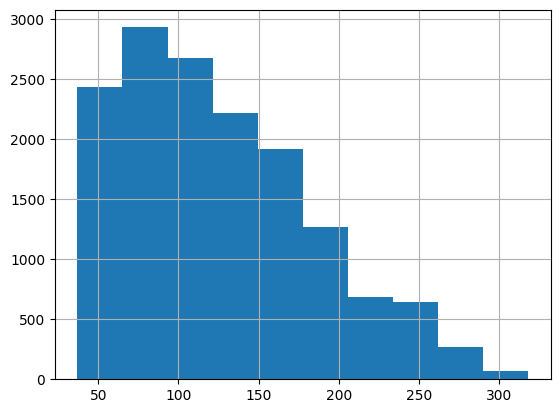

In [5]:
train['month_count'].hist()

<Axes: >

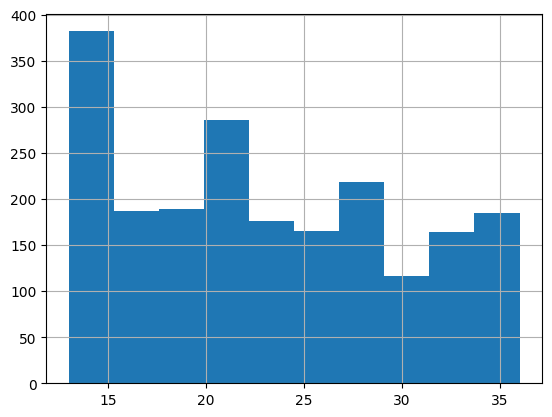

In [6]:
val['month_count'].hist()

<Axes: >

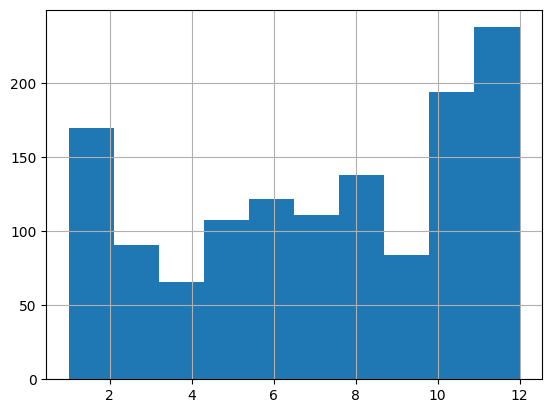

In [7]:
holdout['month_count'].hist()

УДАЛЯЕМ ID и MOUNT_COUNT 

0:	learn: 0.6706107	test: 0.6709622	best: 0.6709622 (0)	total: 6.74ms	remaining: 6.73s
100:	learn: 0.2152157	test: 0.2171073	best: 0.2171073 (100)	total: 535ms	remaining: 4.76s
200:	learn: 0.1739603	test: 0.1767821	best: 0.1767821 (200)	total: 1.14s	remaining: 4.55s
300:	learn: 0.1629590	test: 0.1677991	best: 0.1677991 (300)	total: 1.74s	remaining: 4.05s
400:	learn: 0.1559882	test: 0.1631386	best: 0.1631386 (400)	total: 2.37s	remaining: 3.54s
500:	learn: 0.1512357	test: 0.1604286	best: 0.1604286 (500)	total: 2.95s	remaining: 2.94s
600:	learn: 0.1474632	test: 0.1583346	best: 0.1583346 (600)	total: 3.51s	remaining: 2.33s
700:	learn: 0.1445072	test: 0.1569975	best: 0.1569975 (700)	total: 4.05s	remaining: 1.73s
800:	learn: 0.1418706	test: 0.1559018	best: 0.1559018 (800)	total: 4.59s	remaining: 1.14s
900:	learn: 0.1393741	test: 0.1549720	best: 0.1549720 (900)	total: 5.15s	remaining: 566ms
999:	learn: 0.1369339	test: 0.1542105	best: 0.1542105 (999)	total: 5.7s	remaining: 0us

bestTest = 0.15

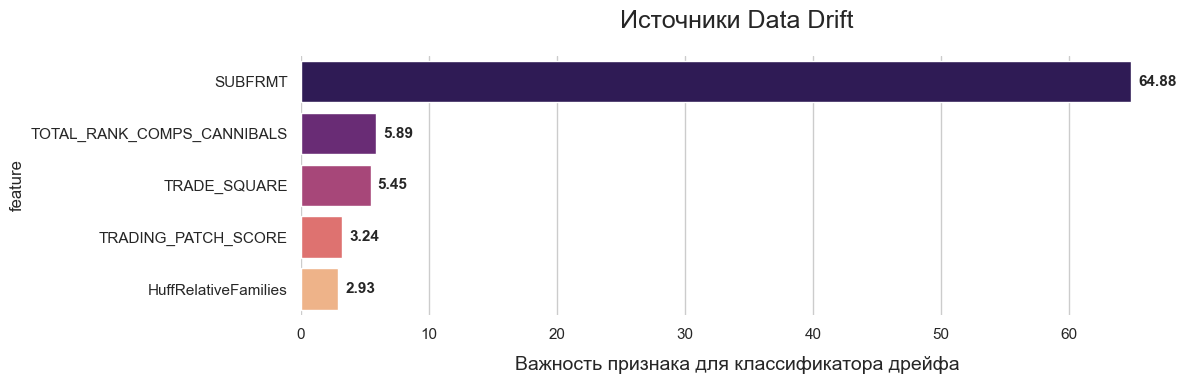

In [20]:
old_data = pd.concat([train, val], axis=0).reset_index(drop=True)
old_data['is_holdout'] = 0
new_data = holdout.copy()
new_data['is_holdout'] = 1
df_adv = pd.concat([old_data, new_data], axis=0).reset_index(drop=True)

features_to_drop = [features[0],features[54], features[55], 'month_count', 'is_holdout']
X = df_adv.drop(columns=[col for col in features_to_drop if col in df_adv.columns])
y = df_adv['is_holdout']

cat_features = features[1:5]

cat_features = [c for c in cat_features if c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=6,
    cat_features=cat_features,
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))

probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print(f"\nROC-AUC Adversarial Validation: {auc:.4f}")

importances = model.get_feature_importance(type='FeatureImportance')
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nТоп признаков, по которым holdout отличается от train/val:")
print(feature_importance_df.head(10))


import seaborn as sns
import matplotlib.pyplot as plt

# 1. Настройка стиля
sns.set_theme(style="whitegrid") # Чистый белый фон с сеткой
plt.figure(figsize=(12, 4))

# 2. Подготовка данных (сортировка для красоты)
plot_data = feature_importance_df.sort_values('importance', ascending=False).head(5)

# 3. Построение графика
# Используем палитру 'viridis' или 'magma' — они выглядят профессионально
ax = sns.barplot(
    x='importance', 
    y='feature', 
    data=plot_data, 
    palette='magma',
    hue='feature', # Для автоматического раскраса
    legend=False
)

# 4. Добавление числовых значений в конце столбцов
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=5, fontsize=11, fontweight='bold')

# 5. Кастомизация текста
plt.title('Источники Data Drift', fontsize=18, pad=20)
plt.xlabel('Важность признака для классификатора дрейфа', fontsize=14, labelpad=10)

# 6. Тонкая настройка границ
sns.despine(left=True, bottom=True) # Убираем лишние рамки

plt.tight_layout()
plt.show()

In [9]:
print("Train SUBFRMT counts:\n", train['SUBFRMT'].value_counts(normalize=True))
print("\nHoldout SUBFRMT counts:\n", holdout['SUBFRMT'].value_counts(normalize=True))

Train SUBFRMT counts:
 SUBFRMT
2    0.595341
1    0.404659
Name: proportion, dtype: float64

Holdout SUBFRMT counts:
 SUBFRMT
1    1.0
Name: proportion, dtype: float64


In [10]:
val['SUBFRMT'].value_counts(normalize=True)

SUBFRMT
1    0.990329
2    0.009671
Name: proportion, dtype: float64

0:	learn: 0.6819723	test: 0.6819455	best: 0.6819455 (0)	total: 7.52ms	remaining: 7.51s
100:	learn: 0.2618652	test: 0.2625300	best: 0.2625300 (100)	total: 548ms	remaining: 4.87s
200:	learn: 0.2112504	test: 0.2136575	best: 0.2136575 (200)	total: 1.09s	remaining: 4.35s
300:	learn: 0.1954608	test: 0.2002227	best: 0.2002227 (300)	total: 1.75s	remaining: 4.06s
400:	learn: 0.1863974	test: 0.1935886	best: 0.1935886 (400)	total: 2.34s	remaining: 3.5s
500:	learn: 0.1803659	test: 0.1894783	best: 0.1894783 (500)	total: 2.91s	remaining: 2.9s
600:	learn: 0.1756275	test: 0.1867533	best: 0.1867533 (600)	total: 3.48s	remaining: 2.31s
700:	learn: 0.1720542	test: 0.1847781	best: 0.1847781 (700)	total: 4.02s	remaining: 1.71s
800:	learn: 0.1692271	test: 0.1833669	best: 0.1833669 (800)	total: 4.57s	remaining: 1.13s
900:	learn: 0.1662824	test: 0.1819769	best: 0.1819769 (900)	total: 5.11s	remaining: 562ms
999:	learn: 0.1633020	test: 0.1809123	best: 0.1809123 (999)	total: 5.67s	remaining: 0us

bestTest = 0.180

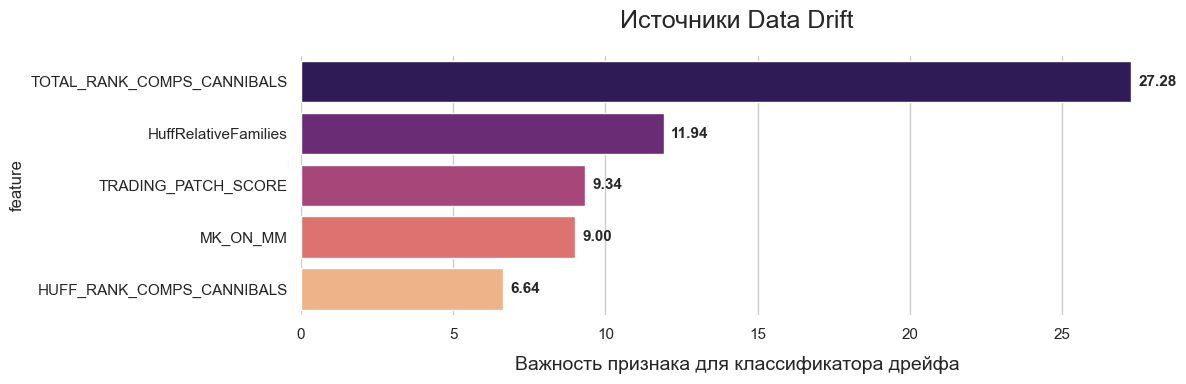

In [21]:
old_data = pd.concat([train, val], axis=0).reset_index(drop=True)
old_data['is_holdout'] = 0
new_data = holdout.copy()
new_data['is_holdout'] = 1
df_adv = pd.concat([old_data, new_data], axis=0).reset_index(drop=True)

df_adv['DIST_TO_ADM_CENTER'] = np.log1p(df_adv['DIST_TO_ADM_CENTER'])

features_to_drop = [features[0],features[54], features[55], 'month_count', 'SUBFRMT','is_holdout']
X = df_adv.drop(columns=[col for col in features_to_drop if col in df_adv.columns])
y = df_adv['is_holdout']

cat_features = features[1:5]

cat_features = [c for c in cat_features if c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=6,
    cat_features=cat_features,
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))

probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print(f"\nROC-AUC Adversarial Validation: {auc:.4f}")


importances = model.get_feature_importance(type='FeatureImportance')
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nТоп признаков, по которым holdout отличается от train/val:")
print(feature_importance_df.head(10))

sns.set_theme(style="whitegrid") # Чистый белый фон с сеткой
plt.figure(figsize=(12, 4))

# 2. Подготовка данных (сортировка для красоты)
plot_data = feature_importance_df.sort_values('importance', ascending=False).head(5)

# 3. Построение графика
# Используем палитру 'viridis' или 'magma' — они выглядят профессионально
ax = sns.barplot(
    x='importance', 
    y='feature', 
    data=plot_data, 
    palette='magma',
    hue='feature', # Для автоматического раскраса
    legend=False
)

# 4. Добавление числовых значений в конце столбцов
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=5, fontsize=11, fontweight='bold')

# 5. Кастомизация текста
plt.title('Источники Data Drift', fontsize=18, pad=20)
plt.xlabel('Важность признака для классификатора дрейфа', fontsize=14, labelpad=10)

# 6. Тонкая настройка границ
sns.despine(left=True, bottom=True) # Убираем лишние рамки

plt.tight_layout()
plt.show()